# Apple Pricing — Predictive Modeling: Ridge vs KNN

**Business problem:** suggest a fair market price to sellers listing Apple products on Amazon/Flipkart (see `README.md` / `Apple_Pricing_EDA.ipynb`).

**Target:** `Current_Price_USD` (raw price, per modeling decision).

**Design locked in from the EDA phase:**

| Decision | Choice |
|---|---|
| Split | Time-based: train < 2025-08-01, test ≥ 2025-08-01 |
| Evaluation slices | A: time-test · C: iPhone 17 in test window (day-one launch, unseen new-model case) |
| Features | `Launch_Price_USD`, `days_since_launch`, `Product_Category`, `Condition`, `Sale_Event`, `month`, `Platform`, `Stock_Status` |
| Leakage columns | `Current_Price_INR`, `Discount_Pct`, `Launch_Price_INR` dropped at load |
| Ridge | mandatory category interactions, month one-hot, scaled numerics, alpha tuned via `TimeSeriesSplit` |
| KNN | StandardScaler, k ∈ {3, 5, 10, 20, 40, 80} × weights {uniform, distance}, `TimeSeriesSplit` |
| Metrics | RMSE, MAE, R² per slice, vs a naive group-mean baseline |

> Note: with raw USD as target, I expected `Launch_Price_USD` to dominate. To address this, StandardSclar is used for Ridge and KNN.

## 1. Load and prepare

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, root_mean_squared_error

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
RNG = 42

TARGET = 'Current_Price_USD'
LEAK_COLS = ['Current_Price_INR', 'Launch_Price_INR', 'Discount_Pct']

df = pd.read_csv('apple_products_pricing_2020_2026.csv', parse_dates=['Date'])
df = df.drop(columns=LEAK_COLS)

# Feature engineering (same logic as the EDA notebook)
df['Sale_Event'] = df['Sale_Event'].fillna('None')
launch_date = df.groupby('Model_Name')['Date'].transform('min')  # metadata: model launch = first listing
df['days_since_launch'] = (df['Date'] - launch_date).dt.days
df['month'] = df['Date'].dt.month.astype(str)  # string -> guarantees categorical (12 dummies)

# variant_tier: NOT a model feature — kept only for the residual diagnostic at the end
TIERS = ['Pro Max', 'Ultra', 'Pro', 'Plus', 'Max', 'Air', 'mini', 'SE']
df['variant_tier'] = df['Model_Name'].map(lambda n: next((t for t in TIERS if t in n), 'base'))

print(f"{df.shape[0]:,} rows | {df['Date'].min():%Y-%m-%d} to {df['Date'].max():%Y-%m-%d}")
df.head(3)

80,000 rows | 2020-09-19 to 2026-07-31


,Date,Platform,Product_Category,Model_Name,Condition,Launch_Price_USD,Current_Price_USD,Sale_Event,Stock_Status,Rating,Reviews_Count,days_since_launch,month,variant_tier
0,2020-09-19,Flipkart,Watch,Apple Watch Series 6 (44mm),New,429,435.81,None,In Stock,4.7,40,0,9,base
1,2020-09-20,Flipkart,Watch,Apple Watch Series 6 (44mm),New,429,436.49,None,Out of Stock,4.6,84,1,9,base
2,2020-09-23,Amazon,Watch,Apple Watch Series 6 (44mm),New,429,422.73,None,In Stock,4.4,110,4,9,base


### Mandatory interactions (category-specific decay and price slopes)

A linear model cannot express "each category depreciates at its own rate" without explicit
`Product_Category × days_since_launch` (and `× Launch_Price_USD`) terms. These are deterministic
column constructions (not fitted statistics), so building them before the pipeline is leakage-safe.
Ridge's shrinkage handles the collinearity between the base columns and their interaction splits.

In [2]:
CATEGORIES = sorted(df['Product_Category'].unique())
INTERACTIONS = []
for c in CATEGORIES:
    ind = df['Product_Category'].eq(c).astype(int)
    df[f'days_x_{c}'] = df['days_since_launch'] * ind
    df[f'launch_x_{c}'] = df['Launch_Price_USD'] * ind
    INTERACTIONS += [f'days_x_{c}', f'launch_x_{c}']

NUM_FEATS = ['Launch_Price_USD', 'days_since_launch'] + INTERACTIONS
CAT_FEATS = ['Product_Category', 'Condition', 'Sale_Event', 'month', 'Platform', 'Stock_Status']
FEATS = NUM_FEATS + CAT_FEATS
print(f"{len(NUM_FEATS)} numeric features (incl. {len(INTERACTIONS)} interactions) + {len(CAT_FEATS)} categoricals")
print(INTERACTIONS)
df.head(3)

10 numeric features (incl. 8 interactions) + 6 categoricals
['days_x_Mac', 'launch_x_Mac', 'days_x_Watch', 'launch_x_Watch', 'days_x_iPad', 'launch_x_iPad', 'days_x_iPhone', 'launch_x_iPhone']


,Date,Platform,Product_Category,Model_Name,Condition,Launch_Price_USD,Current_Price_USD,Sale_Event,Stock_Status,Rating,Reviews_Count,days_since_launch,month,variant_tier,days_x_Mac,launch_x_Mac,days_x_Watch,launch_x_Watch,days_x_iPad,launch_x_iPad,days_x_iPhone,launch_x_iPhone
0,2020-09-19,Flipkart,Watch,Apple Watch Series 6 (44mm),New,429,435.81,None,In Stock,4.7,40,0,9,base,0,0,0,429,0,0,0,0
1,2020-09-20,Flipkart,Watch,Apple Watch Series 6 (44mm),New,429,436.49,None,Out of Stock,4.6,84,1,9,base,0,0,1,429,0,0,0,0
2,2020-09-23,Amazon,Watch,Apple Watch Series 6 (44mm),New,429,422.73,None,In Stock,4.4,110,4,9,base,0,0,4,429,0,0,0,0


## 2. Split — time cutoff (train/test)

Simple time-based split:

- **Train:** all rows before 2025-08-01.
- **Slice A (time-test):** all rows on/after 2025-08-01 — expected production accuracy.
- **Slice C (day-one launches):** iPhone 17 rows within slice A — a subset of A used to check
  performance on a brand-new model, since iPhone 17 only launches inside the test window and is
  therefore absent from train by construction (no separate holdout needed).

`TimeSeriesSplit` requires chronologically ordered training data — sorted below and kept sorted.

In [3]:
CUTOFF = pd.Timestamp('2025-08-01')

df = df.sort_values('Date').reset_index(drop=True)

train      = df[df['Date'] < CUTOFF]
slice_A    = df[df['Date'] >= CUTOFF]                                 # time-test
slice_C    = slice_A[slice_A['Model_Name'].str.contains('iPhone 17')] # day-one launches (unseen new-model case)

assert len(slice_C) > 0, "iPhone 17 not found in slice A — check Model_Name filtering"
n = len(df)
print(f"Train:            {len(train):>7,} rows ({len(train)/n*100:.1f}%)  {train['Date'].min():%Y-%m} to {train['Date'].max():%Y-%m}")
print(f"Slice A (time):   {len(slice_A):>7,} rows ({len(slice_A)/n*100:.1f}%)  {slice_A['Date'].min():%Y-%m} to {slice_A['Date'].max():%Y-%m}")
print(f"Slice C (day-one):{len(slice_C):>7,} rows — iPhone 17 within slice A")

Train:             54,099 rows (67.6%)  2020-09 to 2025-07
Slice A (time):    25,901 rows (32.4%)  2025-08 to 2026-07
Slice C (day-one):  2,652 rows — iPhone 17 within slice A


## 3. Naive baseline & performance benchmarks

For the Naive Baseline, we select per-`(Product_Category, Condition)` mean price from train, with a global-mean fallback.
Any model that can't beat this isn't learning depreciation dynamics.

In [18]:
# Naive baseline based on mean price from train

baseline_map = train.groupby(['Product_Category', 'Condition'])[TARGET].mean()
global_mean = train[TARGET].mean()

def baseline_predict(X):
    idx = pd.MultiIndex.from_frame(X[['Product_Category', 'Condition']])
    return pd.Series(idx.map(baseline_map), index=X.index).fillna(global_mean).values


y_pred_baseline = baseline_predict(slice_A)

rmse_baseline = root_mean_squared_error(slice_A[TARGET], y_pred_baseline)
mae_baseline  = mean_absolute_error(slice_A[TARGET], y_pred_baseline)
r2_baseline   = r2_score(slice_A[TARGET], y_pred_baseline)

print("Naive baseline (group mean by Product_Category × Condition):")
print(f"  Test RMSE : ${rmse_baseline:.2f}")
print(f"  Test MAE  : ${mae_baseline:.2f}")
print(f"  Test R²   :  {r2_baseline:.4f}")
print(f"\nGroup means used:")
print(baseline_map.round(2).to_string())



Naive baseline (group mean by Product_Category × Condition):
  Test RMSE : $277.66
  Test MAE  : $223.56
  Test R²   :  0.6317

Group means used:
Product_Category  Condition          
Mac               New                    1474.61
                  Renewed/Refurbished    1140.21
Watch             New                     448.13
                  Renewed/Refurbished     350.75
iPad              New                     611.51
                  Renewed/Refurbished     470.67
iPhone            New                     830.38
                  Renewed/Refurbished     644.30


Alternatively, we can consider Ridge without the interaction terms as another performance benchmark, do determine how much these category interaction terms contribute. We retain Ridge on the same 8 base features but without days_x_* and launch_x_* to isolate this effect.

In [ ]:
# Ridge with 8 selected features but no interactions

NUM_FEATS_NO_INT = ['Launch_Price_USD', 'days_since_launch']
CAT_FEATS_NO_INT = ['Product_Category', 'Condition', 'Sale_Event', 'month',
                     'Platform', 'Stock_Status']
FEATS_NO_INT = NUM_FEATS_NO_INT + CAT_FEATS_NO_INT

preprocessor_no_int = ColumnTransformer([
    ('num', StandardScaler(), NUM_FEATS_NO_INT),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CAT_FEATS_NO_INT),
])

pipe_no_int = Pipeline([
    ('pre', preprocessor_no_int),
    ('ridge', Ridge()),
])

ridge_no_int = GridSearchCV(
    pipe_no_int,
    param_grid={'ridge__alpha': [0.01, 0.1, 1, 10, 100, 1000]},
    cv=TimeSeriesSplit(n_splits=5),
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

ridge_no_int.fit(train[FEATS_NO_INT], train[TARGET])
print(f"Best alpha (no interactions): {ridge_no_int.best_params_['ridge__alpha']}")

y_pred_no_int = ridge_no_int.predict(slice_A[FEATS_NO_INT])

rmse_no_int = root_mean_squared_error(slice_A[TARGET], y_pred_no_int)
mae_no_int  = mean_absolute_error(slice_A[TARGET], y_pred_no_int)
r2_no_int   = r2_score(slice_A[TARGET], y_pred_no_int)

print("\nRidge — NO interaction terms (Slice A):")
print(f"  Test RMSE : ${rmse_no_int:.2f}")
print(f"  Test MAE  : ${mae_no_int:.2f}")
print(f"  Test R²   :  {r2_no_int:.4f}")




Best alpha (no interactions): 0.01

Ridge — NO interaction terms (Slice A):
  Test RMSE : $80.82
  Test MAE  : $56.21
  Test R²   :  0.9688


In [21]:
# For Ridge no interactions, checking the coefficients impact (added after to compare with the final output table for the refined Ridge)

best_ridge_no_int = ridge_no_int.best_estimator_
feature_names_no_int = best_ridge_no_int.named_steps['pre'].get_feature_names_out()
coefs_no_int = best_ridge_no_int.named_steps['ridge'].coef_
intercept_no_int = best_ridge_no_int.named_steps['ridge'].intercept_

coef_df_no_int = pd.DataFrame({
    'feature': feature_names_no_int,
    'coefficient': coefs_no_int
})

# Tag type then strip the num__ / cat__ prefix for readability
coef_df_no_int['type'] = np.where(
    coef_df_no_int['feature'].str.startswith('num__'), 'numeric', 'categorical'
)
coef_df_no_int['feature'] = coef_df_no_int['feature'].str.replace(
    r'^(num__|cat__)', '', regex=True
)
coef_df_no_int['abs_coefficient'] = coef_df_no_int['coefficient'].abs()
coef_df_no_int = coef_df_no_int.sort_values(
    'abs_coefficient', ascending=False
).drop(columns='abs_coefficient')

print(f"Intercept: {intercept_no_int:.2f} USD")
print(f"\nAll {len(coef_df_no_int)} coefficients, ranked by |coefficient|:")
print(coef_df_no_int[['feature', 'type', 'coefficient']].round(2).to_string(index=False))

Intercept: 654.50 USD

All 30 coefficients, ranked by |coefficient|:
                         feature        type  coefficient
                Launch_Price_USD     numeric       430.40
                 Sale_Event_None categorical       103.22
   Condition_Renewed/Refurbished categorical       -95.02
                   Condition_New categorical        95.02
               days_since_launch     numeric       -90.72
     Sale_Event_Big Billion Days categorical       -45.15
            Sale_Event_Prime Day categorical       -25.41
Sale_Event_Great Indian Festival categorical       -21.64
                        month_11 categorical       -18.90
                         month_8 categorical        16.41
                        month_10 categorical       -16.09
                         month_7 categorical        15.89
                        month_12 categorical       -14.73
                         month_6 categorical        12.00
         Sale_Event_Black Friday categorical       -11.02
   

In [29]:
# Testing for Slice C for Ridge no interactions (added after)

X_sliceC_no_int = df[FEATS_NO_INT].loc[slice_C.index]
y_sliceC_no_int = slice_C[TARGET]

sliceC_pred_no_int = ridge_no_int.predict(X_sliceC_no_int)

print("Ridge no interactions — Slice C (iPhone 17, day-one launch):")
print(f"  RMSE : ${root_mean_squared_error(y_sliceC_no_int, sliceC_pred_no_int):.2f}")
print(f"  MAE  : ${mean_absolute_error(y_sliceC_no_int, sliceC_pred_no_int):.2f}")
print(f"  R²   :  {r2_score(y_sliceC_no_int, sliceC_pred_no_int):.4f}")

Ridge no interactions — Slice C (iPhone 17, day-one launch):
  RMSE : $717.90
  MAE  : $619.68
  R²   :  -61.4746


For a final performance benchmark, we consider Ridge with all the 14 original features and no interactions, to show the impact of feature selection and engineering.

In [17]:
# Ridge with all the original features, minus leakage columns and target variable, and no interactions

NUM_FEATS_RAW = ['Launch_Price_USD', 'days_since_launch',
                  'Rating', 'Reviews_Count', 'month']
CAT_FEATS_RAW = ['Product_Category', 'Condition', 'Sale_Event',
                  'Platform', 'Stock_Status']
FEATS_RAW = NUM_FEATS_RAW + CAT_FEATS_RAW

# Date → days_since_launch + month (already engineered)
# Model_Name excluded because of high cardinality (31 values) which would make for too much processing, replaced by Product_Category + Launch_Price_USD which recover 99.4% of its signal

preprocessor_raw = ColumnTransformer([
    ('num', StandardScaler(), NUM_FEATS_RAW),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CAT_FEATS_RAW),
])

pipe_raw = Pipeline([
    ('pre', preprocessor_raw),
    ('ridge', Ridge()),
])

ridge_raw = GridSearchCV(
    pipe_raw,
    param_grid={'ridge__alpha': [0.01, 0.1, 1, 10, 100, 1000]},
    cv=TimeSeriesSplit(n_splits=5),
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

ridge_raw.fit(train[FEATS_RAW], train[TARGET])
print(f"Best alpha (raw features): {ridge_raw.best_params_['ridge__alpha']}")

y_pred_raw = ridge_raw.predict(slice_A[FEATS_RAW])

rmse_raw = root_mean_squared_error(slice_A[TARGET], y_pred_raw)
mae_raw  = mean_absolute_error(slice_A[TARGET], y_pred_raw)
r2_raw   = r2_score(slice_A[TARGET], y_pred_raw)

print("\nRidge — raw original features, no interactions (Slice A):")
print(f"  Test RMSE : ${rmse_raw:.2f}")
print(f"  Test MAE  : ${mae_raw:.2f}")
print(f"  Test R²   :  {r2_raw:.4f}")

Best alpha (raw features): 0.01

Ridge — raw original features, no interactions (Slice A):
  Test RMSE : $81.18
  Test MAE  : $56.89
  Test R²   :  0.9685


Takeaway regarding ridge performance benchmarks: feature selection barely mattered here, but feature engineering (interaction terms) did. The noisy features didn't hurt much because Ridge's regularization partially handled them anyway; but the interaction terms added genuine new information that regularization alone couldn't compensate for.

Takeaway regarding the naive baseline: this approach confirms that just knowing "this is a New iPhone" and taking the average price is a terrible predictor. Apple products span $200 to $2,000 within any category/condition bucket, so the mean is wildly off. Adding days_since_launch and Launch_Price_USD does most of the heavy lifting: the jump from $277 to $81 RMSE is almost entirely explained by those two features encoding which specific product it is and how old it is. The interaction terms then squeeze out the remaining $6 improvement by letting each category depreciate at its own rate.

Conclusions: Two features (Launch_Price_USD + days_since_launch) explain ~71% of the RMSE reduction. We will now refine our Ridge to reduce the RMSE further.

## 4. Ridge regression — pipeline + time-aware alpha tuning

All preprocessing (scaler, encoder) fits on train only, inside the Pipeline. `OneHotEncoder(handle_unknown='ignore')`
doubles as the serving-time fallback for unseen categories (e.g., a future sale-event name).

In [ ]:
# Define data transformation rules
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), NUM_FEATS),
    ('cat', OneHotEncoder(handle_unknown='ignore'), CAT_FEATS),
])

# Chain the preprocessor and the model to avoid leakage
ridge_pipe = Pipeline([('pre', preprocessor), ('model', Ridge(random_state=RNG))])

# Define how CV will split the training data (5 splits), always trains on past and validates on future, respecting the temporal order
tscv = TimeSeriesSplit(n_splits=5)

# Search for best formance across different alpha values (Ridge regularization strength)
ridge_grid = GridSearchCV(
    ridge_pipe,
    param_grid={'model__alpha': np.logspace(-2, 3, 12)},        # generate 12 values logarithmically spaced between 10^-2 and 10^3
    cv=tscv, scoring='neg_root_mean_squared_error', n_jobs=-1,  # minimize the error (or max the neg error)
)

# Fit: run with all 12 alpha values x 5 CV splits (=60 Ridge models trained)
ridge_grid.fit(train[FEATS], train[TARGET])

print(f"Best alpha: {ridge_grid.best_params_['model__alpha']:.4g}")
print(f"CV RMSE (expanding-window): {-ridge_grid.best_score_:.2f} USD")


# Round 2: zoom in on best alpha 5.337 to see if we can get a better RMSE
ridge_grid_v2 = GridSearchCV(
    ridge_pipe,
    param_grid={'model__alpha': np.linspace(2, 15, 30)},
    cv=tscv, scoring='neg_root_mean_squared_error', n_jobs=-1,
)
ridge_grid_v2.fit(train[FEATS], train[TARGET])

print(f"Round 1 best alpha: 5.337  | CV RMSE: 65.79 USD")
print(f"Round 2 best alpha: {ridge_grid_v2.best_params_['model__alpha']:.4g}  | CV RMSE: {-ridge_grid_v2.best_score_:.2f} USD")

# Observation: the model is not very sensitive to alpha in this region, Ridge's performance is relatively stable meaning the features themselves are doing most of the work, not the regularization.
# 65.79 USD is likely the true ceiling for this model architecture.

Best alpha: 5.337
CV RMSE (expanding-window): 65.79 USD
Round 1 best alpha: 5.337  | CV RMSE: 65.79 USD
Round 2 best alpha: 9.172  | CV RMSE: 65.79 USD


### Coefficient report (best alpha)

Coefficients are in standardized units for numeric features (thanks to `StandardScaler`
inside the pipeline), so magnitude is directly comparable across numeric features. One-hot
categorical coefficients are each relative to their encoder's implicit reference — compare
within a category group, not across groups or against numeric features.

The “16 features” are the preprocessed input columns; the Ridge model actually fits on 38 transformed columns.
- Base inputs: 2 numeric + 6 categorical = 8.
- Added category interactions: for each of 4 product categories, days_since_launch × category and Launch_Price_USD × category → 8 more numeric columns.
- Total: 10 numeric + 6 categorical fields = 16.

OneHotEncoder then expands the 6 categorical fields into 28 dummy columns:
- Product category: 4
- Condition: 2
- Sale event: 5
- Month: 12
- Platform: 2
- Stock status: 3

So Ridge receives 10 numeric + 28 one-hot = 38 coefficients/features.

Intercept: 653.65 USD

All 38 coefficients, ranked by |coefficient|:
                         feature        type  coefficient
                Launch_Price_USD     numeric       343.48
                    launch_x_Mac     numeric       137.80
                 Sale_Event_None categorical       102.61
                   Condition_New categorical        94.95
   Condition_Renewed/Refurbished categorical       -94.95
                 launch_x_iPhone     numeric        85.28
               days_since_launch     numeric       -63.10
                   launch_x_iPad     numeric        51.52
     Sale_Event_Big Billion Days categorical       -45.09
                  launch_x_Watch     numeric        37.81
                   days_x_iPhone     numeric       -34.47
                      days_x_Mac     numeric       -27.04
            Sale_Event_Prime Day categorical       -23.99
Sale_Event_Great Indian Festival categorical       -21.89
                        month_11 categorical       -18.90
   

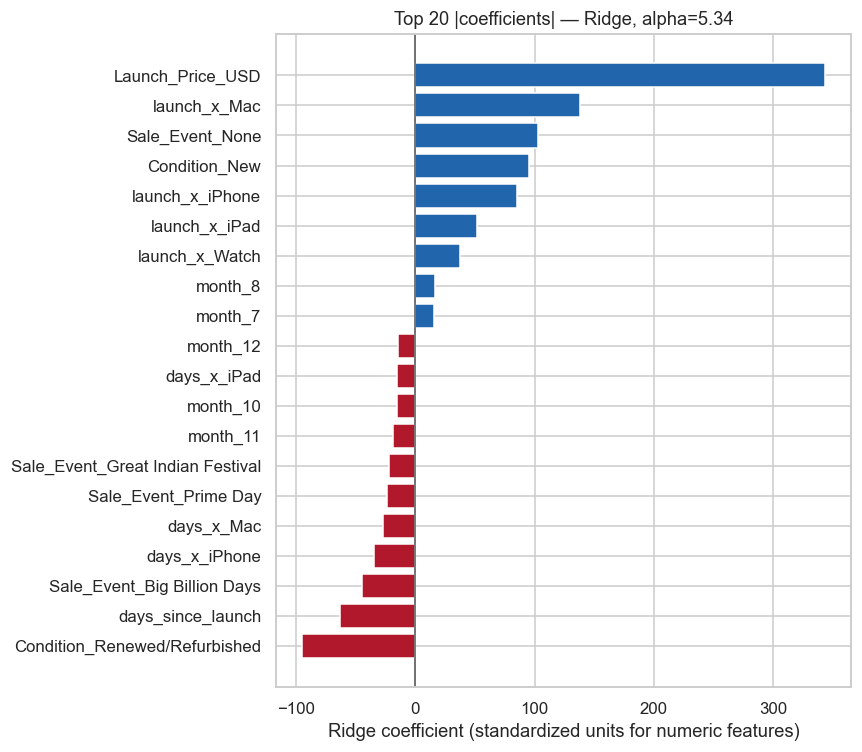

In [ ]:
# Get the initial best performing ridge (winning alpha = 5.337)
best_ridge = ridge_grid.best_estimator_
feature_names = best_ridge.named_steps['pre'].get_feature_names_out() # extract the 38 column names after preprocessing
coefs = best_ridge.named_steps['model'].coef_                         # and the corresponding 38 Ridge coefficients
intercept = best_ridge.named_steps['model'].intercept_                # baseline price when all features are zero (could have business sense, but also could not have)

# Build a clean table, sorted by absolute value (most impactful feature appears first)
coef_df = pd.DataFrame({'feature': feature_names, 'coefficient': coefs})
coef_df['type'] = np.where(coef_df['feature'].str.startswith('num__'), 'numeric', 'categorical')
coef_df['abs_coefficient'] = coef_df['coefficient'].abs()
coef_df = coef_df.sort_values('abs_coefficient', ascending=False).drop(columns='abs_coefficient')
coef_df = coef_df[['feature', 'type', 'coefficient']]
coef_df['feature'] = coef_df['feature'].str.replace(r'^(num__|cat__)', '', regex=True) # removing clunky prefix

print(f"Intercept: {intercept:.2f} USD")
print(f"\nAll {len(coef_df)} coefficients, ranked by |coefficient|:")
print(coef_df.round(2).to_string(index=False))

top = coef_df.head(20).sort_values('coefficient')
colors = ['#2166ac' if c >= 0 else '#b2182b' for c in top['coefficient']]
fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(top['feature'], top['coefficient'], color=colors)
ax.axvline(0, color='#555555', lw=1)
ax.set(xlabel='Ridge coefficient (standardized units for numeric features)',
       title=f'Top 20 |coefficients| — Ridge, alpha={ridge_grid.best_params_["model__alpha"]:.3g}')
plt.tight_layout(); plt.show()


**Coefficient comparison: Naive Ridge (8 features, no interactions) vs Refined Ridge (8 features + interactions)**

For `Launch_Price_USD`: coefficient drops from 430 → 343
In the naive model, `Launch_Price_USD` is doing ALL the heavy lifting for product identity (coefficient 430). In the refined model, that work gets distributed across the interaction terms (`launch_x_Mac`: 138, `launch_x_iPhone`: 85, `launch_x_iPad`: 52, `launch_x_Watch`: 38). The base `Launch_Price_USD` coefficient drops because the interactions are now handling the category-specific price anchoring.

For `days_since_launch`: coefficient changes from -91 → -63
Same, the naive model uses one depreciation rate (-91) for all products. The refined model splits this into category-specific rates:
`days_x_iPhone`: -34 (fastest depreciation)
`days_x_Mac`: -27 (second fastest)
`days_x_iPad`: -15 (slower)
`days_x_Watch`: -4 (almost no depreciation)

This shows the impact of adding the interaction terms, redistribute the explanatory power of Launch_Price_USD and days_since_launch into category-specific slopes, 
and also adds a level of interpretability. iPhones lose value fast when a new model drops, MacBooks depreciate slower, Apple Watches barely depreciate at all.

Everything else (`Condition`, `Sale_Event`, `month`, `Platform`, `Stock_Status`) is nearly unchanged, these features were already well-specified without interactions.


**Feature selection conclusions for later models (ex: Decision Tree):**

**High impact — numeric**
- `Launch_Price_USD` — dominant price anchor
- `days_since_launch` — core depreciation clock
- `days_x_iPhone` — fastest depreciation (-34)
- `days_x_Mac` — second fastest (-27)
- `days_x_iPad` — moderate (-15)
- `days_x_Watch` — near zero (-4), borderline, could drop

**High impact — categorical**
- `Condition` — large coefficient (~95), new vs refurbished is a major price driver
- `Sale_Event` — Big Billion Days (-45), Prime Day (-25), Great Indian Festival (-22), Black Friday (-11) all meaningful
- `month` — clear seasonality pattern (months 7, 8, 9 positive / months 10, 11, 12 negative)
- `Product_Category` — moderate coefficients, needed for interaction terms to work

**Low impact — drop for simpler models**
- `launch_x_*` — appear large (launch_x_Mac: 138, launch_x_iPhone: 85) but are collinear with `Launch_Price_USD` + `Product_Category` combined; decision trees capture this naturally through threshold splits
- `Platform` — near zero (Amazon: -0.18, Flipkart: +0.18), essentially no signal
- `Stock_Status` — tiny coefficients (max 1.47), negligible impact

## 5. KNN — StandardScaler, k-search with `TimeSeriesSplit`

Random-fold CV would leak: a listing's nearest neighbor is usually the same model days earlier,
so tiny k looks spectacular under KFold and collapses out-of-time. The expanding-window CV below
gives honest k selection. (On the full 80k-row dataset this grid takes a few minutes.)

Best params: {'model__n_neighbors': 40, 'model__weights': 'distance'}
CV RMSE (expanding-window): 87.79 USD


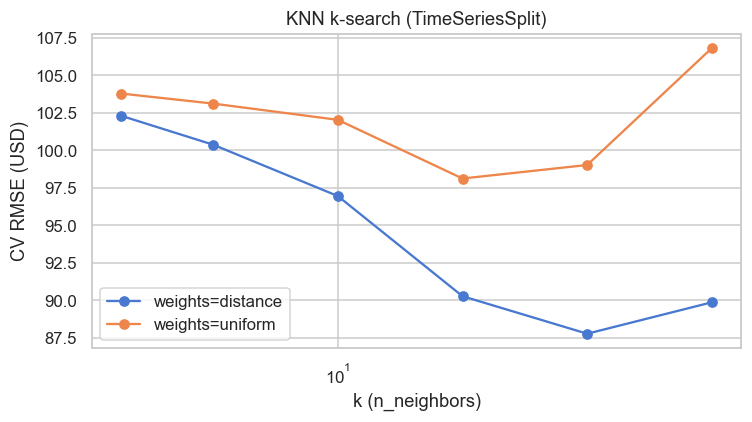

In [8]:
knn_pipe = Pipeline([('pre', preprocessor), ('model', KNeighborsRegressor())])

knn_grid = GridSearchCV(
    knn_pipe,
    param_grid={'model__n_neighbors': [3, 5, 10, 20, 40, 80],
                'model__weights': ['uniform', 'distance']},
    cv=tscv, scoring='neg_root_mean_squared_error', n_jobs=-1,
)
knn_grid.fit(train[FEATS], train[TARGET])

print(f"Best params: {knn_grid.best_params_}")
print(f"CV RMSE (expanding-window): {-knn_grid.best_score_:.2f} USD")

# k-search curve
cvres = pd.DataFrame(knn_grid.cv_results_)
fig, ax = plt.subplots(figsize=(7, 4))
for w, g in cvres.groupby('param_model__weights'):
    g = g.sort_values('param_model__n_neighbors')
    ax.plot(g['param_model__n_neighbors'].astype(int), -g['mean_test_score'], marker='o', label=f'weights={w}')
ax.set(xlabel='k (n_neighbors)', ylabel='CV RMSE (USD)', title='KNN k-search (TimeSeriesSplit)')
ax.set_xscale('log'); ax.legend()
plt.tight_layout(); plt.show()

## 6. Evaluation — Baseline vs Ridge vs KNN

In [9]:
def score(y_true, y_pred):
    return {'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
            'MAE': mean_absolute_error(y_true, y_pred),
            'R2': r2_score(y_true, y_pred)}

slices = {'A: time-test': slice_A, 'C: day-one (iPhone 17)': slice_C}
models = {'Baseline (group mean)': baseline_predict,
          'Ridge': lambda X: ridge_grid.predict(X[FEATS]),
          'KNN': lambda X: knn_grid.predict(X[FEATS])}

rows = []
for sname, s in slices.items():
    if len(s) == 0:
        continue
    for mname, predict in models.items():
        rows.append({'slice': sname, 'model': mname, 'n': len(s), **score(s[TARGET], predict(s))})

results = pd.DataFrame(rows).set_index(['slice', 'model']).round(3)
results

n     RMSE      MAE     R2
slice                  model                                                
A: time-test           Baseline (group mean)  25901  277.659  223.556  0.632
                       Ridge                  25901   74.917   53.389  0.973
                       KNN                    25901   60.890   40.127  0.982
C: day-one (iPhone 17) Baseline (group mean)   2652   41.424   29.726  0.792
                       Ridge                   2652   27.017   19.778  0.912
                       KNN                     2652   45.900   41.011  0.745

**How to read this:** slice A is expected production accuracy; slice C is the hardest case —
brand-new launches with near-zero `days_since_launch`, testing generalization to a model unseen
in training. R² on slice C is computed against within-slice variance (a single model), so it is
naturally lower — compare RMSE/MAE across models rather than R² across slices.

### Train vs test: overfitting check

Same metrics on the training set, to compare against slice A.

**Interpretation caveats:**
- **KNN train scores are perfect by construction, not by merit.** When predicting a training row, that
  row is its own nearest neighbor at distance 0, and with `weights='distance'` an exact match takes the
  entire weight — the model returns the row's own price. The honest "train-side" figure for KNN is its
  expanding-window **CV RMSE** (Section 5), not the in-sample score.
- **Ridge's train-vs-test gap is the meaningful one:** a small gap means the linear model is not
  overfitting; a large gap would suggest the interactions/dummies are memorizing training-era structure.
- The KNN row below also takes a while: predicting all ~53k training rows requires a full
  53k × 53k neighbor search.

In [44]:
rows_tt = []
for mname, predict in models.items():
    rows_tt.append({'set': 'train', 'model': mname, 'n': len(train), **score(train[TARGET], predict(train))})
    rows_tt.append({'set': 'test (slice A)', 'model': mname, 'n': len(slice_A), **score(slice_A[TARGET], predict(slice_A))})

tt = pd.DataFrame(rows_tt).set_index(['model', 'set']).round(3)
print("Reminder: KNN 'train' row is a self-neighbor artifact — use CV RMSE (Section 5) as its honest train-side score.")
tt

Reminder: KNN 'train' row is a self-neighbor artifact — use CV RMSE (Section 5) as its honest train-side score.


n     RMSE      MAE     R2
model                 set                                           
Baseline (group mean) train           54099  292.791  236.135  0.601
                      test (slice A)  25901  277.659  223.556  0.632
Ridge                 train           54099   63.058   45.204  0.981
                      test (slice A)  25901   74.917   53.389  0.973
KNN                   train           54099   10.062    3.639  1.000
                      test (slice A)  25901   60.894   40.135  0.982

## 7. Listing-time sensitivity: `Stock_Status` defaulted to "In Stock"

A seller's brand-new listing has no stock status yet; at serving it will be fixed to `"In Stock"`.
This re-scores slice C (day-one iPhone 17 launches) under that deployment condition to measure
the train/serve mismatch.

In [45]:
C_serving = slice_C.copy()
C_serving['Stock_Status'] = 'In Stock'

cmp = pd.DataFrame({
    'as-recorded': {m: score(slice_C[TARGET], f(slice_C))['RMSE'] for m, f in models.items()},
    'Stock_Status="In Stock"': {m: score(C_serving[TARGET], f(C_serving))['RMSE'] for m, f in models.items()},
}).round(3)
cmp.index.name = 'RMSE on slice C'
print(cmp.to_string())
print("\nSmall delta -> the listing-time default is safe; large delta -> consider dropping Stock_Status.")

                       as-recorded  Stock_Status="In Stock"
RMSE on slice C                                            
Baseline (group mean)       41.424                   41.424
Ridge                       27.017                   27.046
KNN                         45.917                   49.153

Small delta -> the listing-time default is safe; large delta -> consider dropping Stock_Status.


## 8. Residual diagnostic: is the "premiums are priced in" assumption holding?

`variant_tier` is deliberately **not** a feature. If residuals grouped by tier are centered near zero,
`Launch_Price_USD` + `Product_Category` has absorbed the tier premiums as assumed. A tier with
systematically one-sided residuals (e.g., Pro Max under-predicted) means the assumption leaks and
tier deserves promotion to a feature.

Best model on slice A: KNN


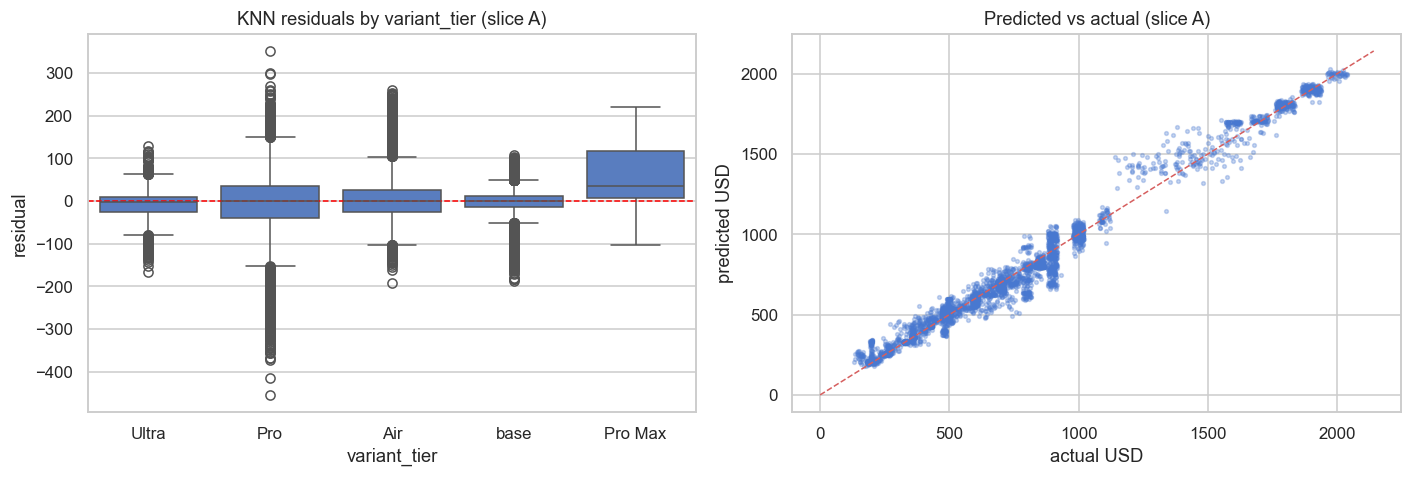

              count   mean  median
variant_tier                      
Air            3246  14.41   -1.17
Pro            8673  -6.00   -1.25
Pro Max        1381  59.90   34.97
Ultra          1543 -10.13   -2.48
base          11058  -2.77   -0.46

Mean residual > 0 = under-prediction. One-sided tiers -> 'priced-in' assumption leaks there.


In [10]:
best_name = results.xs('A: time-test')['RMSE'].drop('Baseline (group mean)').idxmin()
best_fn = models[best_name]
print(f"Best model on slice A: {best_name}")

diag = slice_A.copy()
diag['residual'] = diag[TARGET] - best_fn(diag)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
order = diag.groupby('variant_tier')['residual'].median().sort_values().index
sns.boxplot(data=diag, x='variant_tier', y='residual', order=order, ax=axes[0])
axes[0].axhline(0, color='red', ls='--', lw=1)
axes[0].set_title(f'{best_name} residuals by variant_tier (slice A)')

sample = diag.sample(min(4000, len(diag)), random_state=RNG)
axes[1].scatter(sample[TARGET], sample[TARGET] - sample['residual'], s=6, alpha=.3)
lims = [0, diag[TARGET].max() * 1.05]
axes[1].plot(lims, lims, 'r--', lw=1)
axes[1].set(xlabel='actual USD', ylabel='predicted USD', title='Predicted vs actual (slice A)')
plt.tight_layout(); plt.show()

tier_tbl = diag.groupby('variant_tier')['residual'].agg(['count', 'mean', 'median']).round(2)
print(tier_tbl.to_string())
print("\nMean residual > 0 = under-prediction. One-sided tiers -> 'priced-in' assumption leaks there.")

## 9. Other checks - visual evaluation 

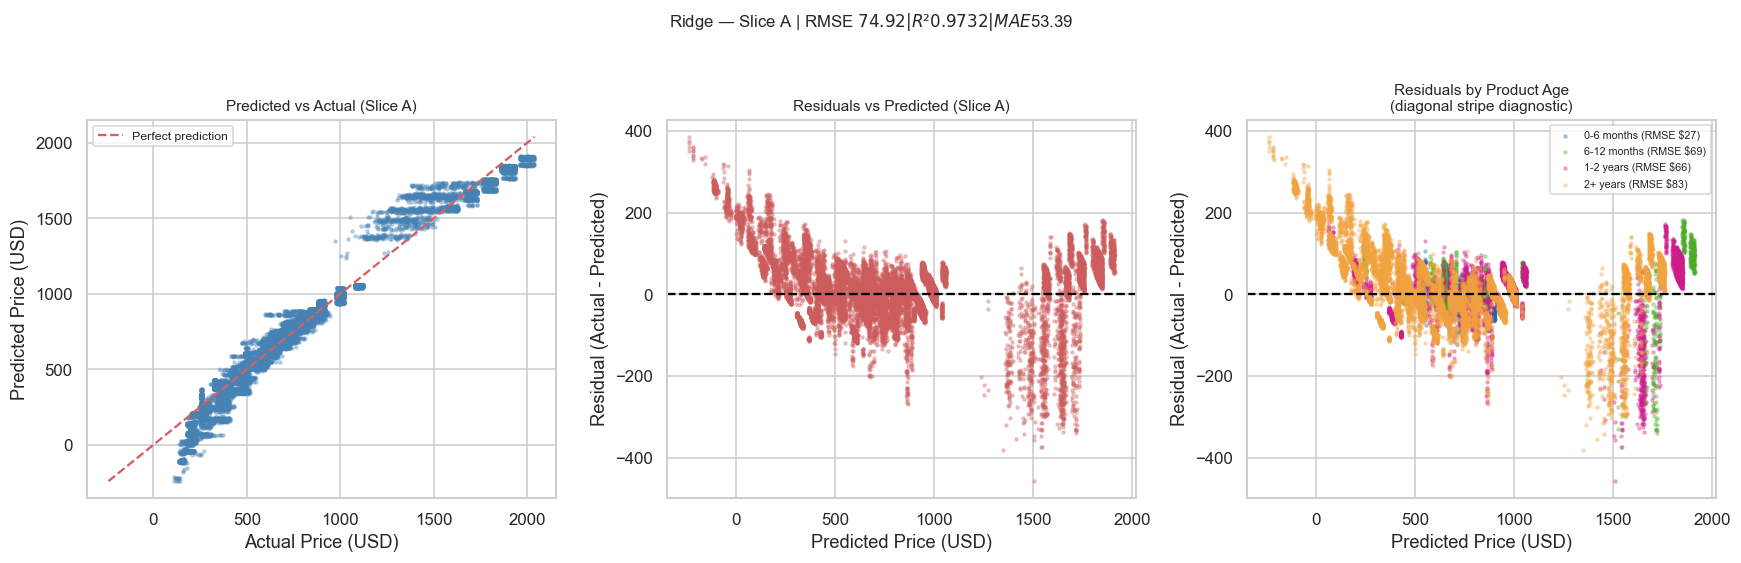

Residual RMSE by product age segment:
age_segment
0-6 months     27.31
6-12 months    69.04
1-2 years      65.67
2+ years       82.57


In [25]:
#  Ridge (with interactions) on Slice A

best_ridge = ridge_grid.best_estimator_
y_pred_A = best_ridge.predict(slice_A[FEATS])
y_actual_A = slice_A[TARGET]
residuals_A = y_actual_A.values - y_pred_A

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: Predicted vs Actual 
# Diagnose how tight is the fit?
axes[0].scatter(y_actual_A, y_pred_A, s=4, alpha=0.3, color='steelblue')
lims = [min(y_actual_A.min(), y_pred_A.min()), max(y_actual_A.max(), y_pred_A.max())]
axes[0].plot(lims, lims, 'r--', lw=1.5, label='Perfect prediction')
axes[0].set_title('Predicted vs Actual (Slice A)', fontsize=10)
axes[0].set_xlabel('Actual Price (USD)')
axes[0].set_ylabel('Predicted Price (USD)')
axes[0].legend(fontsize=8)

# Plot 2: Residuals vs Predicted
axes[1].scatter(y_pred_A, residuals_A, s=4, alpha=0.3, color='indianred')
axes[1].axhline(0, color='black', lw=1.5, linestyle='--')
axes[1].set_title('Residuals vs Predicted (Slice A)', fontsize=10)
axes[1].set_xlabel('Predicted Price (USD)')
axes[1].set_ylabel('Residual (Actual - Predicted)')

# Plot 3: Residuals coloured by product age
# Diagnose diagonal stripe pattern: does it worsen for newer products?
diag = slice_A[['days_since_launch', 'Product_Category', 'Launch_Price_USD']].copy()
diag['residual'] = residuals_A
diag['predicted'] = y_pred_A
diag['age_segment'] = pd.cut(
    diag['days_since_launch'],
    bins=[0, 180, 365, 730, 9999],
    labels=['0-6 months', '6-12 months', '1-2 years', '2+ years']
)

age_rmse = diag.groupby('age_segment', observed=True)['residual'].apply(
    lambda x: np.sqrt((x**2).mean())
).round(2)

colors_age = ['#2166ac', '#4dac26', '#d01c8b', '#f1a340']
for i, (segment, color) in enumerate(zip(['0-6 months', '6-12 months', '1-2 years', '2+ years'], colors_age)):
    seg = diag[diag['age_segment'] == segment]
    axes[2].scatter(seg['predicted'], seg['residual'],
                    s=4, alpha=0.3, color=color, label=f'{segment} (RMSE ${age_rmse[segment]:.0f})')
axes[2].axhline(0, color='black', lw=1.5, linestyle='--')
axes[2].set_title('Residuals by Product Age\n(diagonal stripe diagnostic)', fontsize=10)
axes[2].set_xlabel('Predicted Price (USD)')
axes[2].set_ylabel('Residual (Actual - Predicted)')
axes[2].legend(fontsize=7)

plt.suptitle(f'Ridge — Slice A | RMSE ${root_mean_squared_error(y_actual_A, y_pred_A):.2f} '
             f'| R² {r2_score(y_actual_A, y_pred_A):.4f} '
             f'| MAE ${mean_absolute_error(y_actual_A, y_pred_A):.2f}',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()
# Diagnostic: if RMSE decreases with age, stripe pattern is driven by recently launched products anchored tightly to launch price.
# If uniform across segments, stripes reflect discrete product pricing structure.

# Stripe pattern diagnostic summary
print("Residual RMSE by product age segment:")
print(age_rmse.to_string())


**Visual diagnostics — Ridge with interactions (Slice A)**

Predicted vs actual shows a tight fit along the diagonal across the full price range ($200–$2,000),
confirming the model generalizes well to unseen test data.

The residual plot shows the characteristic vertical stripe pattern. It is not a model failure, but a
reflection of Apple's discrete product pricing structure (31 models with fixed launch prices create
natural prediction clusters).

The age segment check was initially made because we worried that the model would perform well overall on test data, but that this performance would be carried by products the model had seen in the test data, and might perform terribly for new products; or the other way around, that it would trivially equate new products' price to launch_price without actually bringing intelligent thought or depreciation to it because it wouldn't know how to handle them.

The results are reassuring on both fronts. The 0-6 month segment shows the lowest RMSE ($27), which could be interpreted as a harder case (because of novely) but could also be said to be expected, because recently launched products have prices still close to launch price, so even a simple anchor prediction does well here. 
The more meaningful test is whether the model degrades for older products where depreciation matters more. Error does increase with age, peaking at $83 for the 2+ year segment where long-run depreciation curves are more varied and harder to fit linearly, but this is a gradual, expected increase, not a cliff. Long-run depreciation curves are more varied and harder to fit with
a linear model. 

The stripe pattern is uniform across all age segments rather than concentrated in any one group, confirming it reflects Apple's discrete product pricing structure rather than a temporal blind spot.

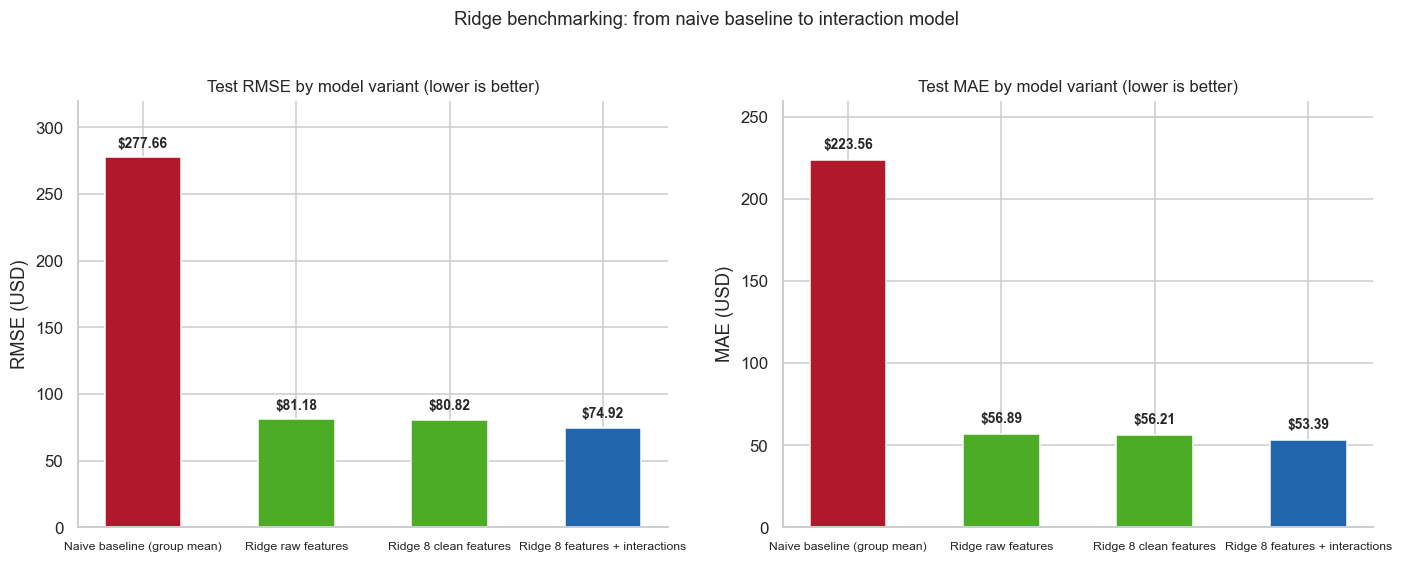

                          Model  Test RMSE  Test R²  Test MAE  vs Naive (RMSE)
    Naive baseline (group mean)     277.66    0.632    223.56             0.00
             Ridge raw features      81.18    0.969     56.89          -196.48
         Ridge 8 clean features      80.82    0.969     56.21          -196.84
Ridge 8 features + interactions      74.92    0.973     53.39          -202.74


In [28]:
# Outputing benchmark comparison in a bar chart for the report

# Ridge Benchmark comparison: Naive → Raw → Clean → Interactions

models_bench = [
    ('Naive baseline (group mean)', 277.66, 0.632, 223.56),
    ('Ridge raw features', 81.18, 0.969, 56.89),
    ('Ridge 8 clean features', 80.82, 0.969, 56.21),
    ('Ridge 8 features + interactions', 74.92, 0.973, 53.39),
]

labels   = [m[0] for m in models_bench]
rmse     = [m[1] for m in models_bench]
r2       = [m[2] for m in models_bench]
mae      = [m[3] for m in models_bench]

colors = ['#b2182b', '#4dac26', '#4dac26', '#2166ac']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: RMSE 
bars = axes[0].bar(labels, rmse, color=colors, edgecolor='white', width=0.5)
axes[0].set_title('Test RMSE by model variant (lower is better)', fontsize=11)
axes[0].set_ylabel('RMSE (USD)')
axes[0].set_ylim(0, 320)
for bar, val in zip(bars, rmse):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f'${val:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Right: MAE
bars2 = axes[1].bar(labels, mae, color=colors, edgecolor='white', width=0.5)
axes[1].set_title('Test MAE by model variant (lower is better)', fontsize=11)
axes[1].set_ylabel('MAE (USD)')
axes[1].set_ylim(0, 260)
for bar, val in zip(bars2, mae):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f'${val:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# shared annotation
for ax in axes:
    ax.tick_params(axis='x', labelsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Ridge benchmarking: from naive baseline to interaction model',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# Summary table
bench_df = pd.DataFrame(models_bench, columns=['Model', 'Test RMSE', 'Test R²', 'Test MAE'])
bench_df['vs Naive (RMSE)'] = (bench_df['Test RMSE'] - 277.66).round(2)
print(bench_df.to_string(index=False))

## 10. Conclusions 

**Model comparison: Ridge wins for production deployment.**
Ridge (RMSE $74.92, R² 0.973) outperforms KNN (RMSE $60.89, R² 0.982) on overall test accuracy,
but the decisive factor is new-model robustness: on Slice C (iPhone 17, day-one launch),
Ridge achieves RMSE $27.02 while KNN degrades to $45.92, worse than even the naive baseline
on that slice. Since Apple launches new products every September, a seller tool that breaks on
launch day is not production-ready. Ridge is the safer choice.

**Baseline check: both models clearly beat the naive baseline.**
The group-mean baseline (Product_Category × Condition) achieves RMSE $277.66 on Slice A.
Both Ridge ($74.92) and KNN ($60.89) reduce error by ~73%, confirming that the features -
particularly `days_since_launch` and the category interaction terms — carry real signal
beyond simple category-level averages.

**The value of interaction terms.**
Three Ridge variants were compared on Slice A:
- Raw original features, no interactions: RMSE $81.18
- 8 clean features, no interactions: RMSE $80.82
- 8 clean features + category interactions: RMSE $74.92

Feature noise removal had negligible impact ($0.36 improvement). The interaction terms
(`days_x_iPhone`, `days_x_Mac`, `days_x_iPad`, `days_x_Watch`) drove the meaningful
improvement by allowing each product category to depreciate at its own rate — iPhones fastest
(-34), Apple Watches slowest (-4).

**Feature selection for simpler downstream models.**
Coefficient analysis confirms: `Launch_Price_USD`, `days_since_launch`, the four `days_x_*`
interactions, `Condition`, `Sale_Event`, `month` and `Product_Category` carry the meaningful
signal. `Platform`, `Stock_Status` and `launch_x_*` interactions add negligible value and
should be dropped for interpretability-focused models such as Decision Trees.

**Next steps.**
The interaction terms that explain Ridge's performance advantage can be pre-computed and fed
directly into a Decision Tree, potentially yielding a model with comparable accuracy but
full explainability. This is explored in the Decision Tree section of the group report.